In [1]:
!apt-get update -qq
!apt-get install -y -qq mpich

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libslurm37.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libslurm37_21.08.5-2ubuntu1_amd64.deb ...
Unpacking libslurm37 (21.08.5-2ubuntu1) ...
Selecting previously unselected package hwloc-nox.
Preparing to unpack .../hwloc-nox_2.7.0-2ubuntu1_amd64.deb ...
Unpacking hwloc-nox (2.7.0-2ubuntu1) ...
Selecting previously unselected package libmpich12:amd64.
Preparing to unpack .../libmpich12_4.0-3_amd64.deb ...
Unpacking libmpich12:amd64 (4.0-3) ...
Selecting previously unselected package mpich.
Preparing to unpack .../archives/mpich_4.0-3_amd64.deb ...
Unpacking mpich (4.0-3) ...
Selecting previously unselected package libmpich-dev:amd64.
Preparing to unpack .../libmpich-dev_4.0-3_amd64.deb ...
Unpacking libmpich

In [2]:
%%writefile mpi_quicksort.cpp
#include <mpi.h>
#include <iostream>
#include <vector>
#include <algorithm>
#include <cstdlib>
#include <ctime>
#include <fstream>
using namespace std;

// --------------------------------------------------
// Sequential quicksort
// --------------------------------------------------
void quicksort(vector<int>& arr, int low, int high) {
    if (low < high) {
        int pivot = arr[high];
        int i = low - 1;

        for (int j = low; j < high; j++) {
            if (arr[j] <= pivot) {
                i++;
                swap(arr[i], arr[j]);
            }
        }

        swap(arr[i + 1], arr[high]);
        int pi = i + 1;

        quicksort(arr, low, pi - 1);
        quicksort(arr, pi + 1, high);
    }
}

// --------------------------------------------------
// Merge sorted chunks
// --------------------------------------------------
vector<int> mergeTwo(const vector<int>& a, const vector<int>& b) {
    vector<int> result;
    int i = 0, j = 0;

    while (i < a.size() && j < b.size()) {
        if (a[i] <= b[j]) result.push_back(a[i++]);
        else result.push_back(b[j++]);
    }

    while (i < a.size()) result.push_back(a[i++]);
    while (j < b.size()) result.push_back(b[j++]);

    return result;
}

// --------------------------------------------------
// Main
// --------------------------------------------------
int main(int argc, char* argv[]) {
    MPI_Init(&argc, &argv);

    int rank, size;
    MPI_Comm_rank(MPI_COMM_WORLD, &rank);
    MPI_Comm_size(MPI_COMM_WORLD, &size);

    if (argc < 2) {
        if (rank == 0) {
            cout << "Usage: mpirun -np <p> ./mpi_quicksort <array_size>\n";
        }
        MPI_Finalize();
        return 0;
    }

    int n = atoi(argv[1]);
    vector<int> arr;
    vector<int> original;

    if (rank == 0) {
        srand(time(0));
        arr.resize(n);
        for (int i = 0; i < n; i++) {
            arr[i] = rand() % 100000;
        }
        original = arr;
    }

    // -----------------------------
    // Sequential quicksort timing
    // -----------------------------
    double seq_time = 0.0;
    if (rank == 0) {
        double seq_start = MPI_Wtime();
        quicksort(arr, 0, n - 1);
        double seq_end = MPI_Wtime();
        seq_time = seq_end - seq_start;
    }

    // -----------------------------
    // Parallel quicksort
    // -----------------------------
    int chunk_size = n / size;
    vector<int> local_arr(chunk_size);

    vector<int> sendbuf;
    if (rank == 0) {
        sendbuf.resize(chunk_size * size);
        for (int i = 0; i < chunk_size * size; i++) {
            sendbuf[i] = original[i];
        }
    }

    MPI_Barrier(MPI_COMM_WORLD);
    double par_start = MPI_Wtime();

    MPI_Scatter(sendbuf.data(), chunk_size, MPI_INT,
                local_arr.data(), chunk_size, MPI_INT,
                0, MPI_COMM_WORLD);

    quicksort(local_arr, 0, chunk_size - 1);

    vector<int> gathered;
    if (rank == 0) {
        gathered.resize(chunk_size * size);
    }

    MPI_Gather(local_arr.data(), chunk_size, MPI_INT,
               gathered.data(), chunk_size, MPI_INT,
               0, MPI_COMM_WORLD);

    double par_end = MPI_Wtime();
    double par_time = par_end - par_start;

    // -----------------------------
    // Root merges sorted chunks
    // -----------------------------
    if (rank == 0) {
        vector<int> merged(gathered.begin(), gathered.begin() + chunk_size);

        for (int i = 1; i < size; i++) {
            vector<int> next_chunk(
                gathered.begin() + i * chunk_size,
                gathered.begin() + (i + 1) * chunk_size
            );
            merged = mergeTwo(merged, next_chunk);
        }

        double speedup = seq_time / par_time;
        double efficiency = speedup / size;

        cout << "Array Size   : " << n << "\n";
        cout << "Processes    : " << size << "\n";
        cout << "Sequential Time : " << seq_time << " sec\n";
        cout << "Parallel Time   : " << par_time << " sec\n";
        cout << "Speedup         : " << speedup << "\n";
        cout << "Efficiency      : " << efficiency << "\n";

        // save results
        ofstream fout("results.csv", ios::app);
        fout << n << "," << size << "," << seq_time << "," << par_time << ","
             << speedup << "," << efficiency << "\n";
        fout.close();
    }

    MPI_Finalize();
    return 0;
}

Writing mpi_quicksort.cpp


In [5]:
!mpic++ mpi_quicksort.cpp -o mpi_quicksort

!echo "array_size,processes,sequential_time,parallel_time,speedup,efficiency" > results.csv

!OMPI_ALLOW_RUN_AS_ROOT=1 OMPI_ALLOW_RUN_AS_ROOT_CONFIRM=1 mpirun --oversubscribe -np 2 ./mpi_quicksort 20000
!OMPI_ALLOW_RUN_AS_ROOT=1 OMPI_ALLOW_RUN_AS_ROOT_CONFIRM=1 mpirun --oversubscribe -np 4 ./mpi_quicksort 20000
!OMPI_ALLOW_RUN_AS_ROOT=1 OMPI_ALLOW_RUN_AS_ROOT_CONFIRM=1 mpirun --oversubscribe -np 2 ./mpi_quicksort 40000
!OMPI_ALLOW_RUN_AS_ROOT=1 OMPI_ALLOW_RUN_AS_ROOT_CONFIRM=1 mpirun --oversubscribe -np 4 ./mpi_quicksort 40000
!OMPI_ALLOW_RUN_AS_ROOT=1 OMPI_ALLOW_RUN_AS_ROOT_CONFIRM=1 mpirun --oversubscribe -np 2 ./mpi_quicksort 80000
!OMPI_ALLOW_RUN_AS_ROOT=1 OMPI_ALLOW_RUN_AS_ROOT_CONFIRM=1 mpirun --oversubscribe -np 4 ./mpi_quicksort 80000

Array Size   : 20000
Processes    : 2
Sequential Time : 0.00925194 sec
Parallel Time   : 0.00514273 sec
Speedup         : 1.79903
Efficiency      : 0.899515
Array Size   : 20000
Processes    : 4
Sequential Time : 0.0289241 sec
Parallel Time   : 0.0116041 sec
Speedup         : 2.49257
Efficiency      : 0.623142
Array Size   : 40000
Processes    : 2
Sequential Time : 0.0224598 sec
Parallel Time   : 0.0113025 sec
Speedup         : 1.98716
Efficiency      : 0.993581
Array Size   : 40000
Processes    : 4
Sequential Time : 0.0401807 sec
Parallel Time   : 0.0154399 sec
Speedup         : 2.60239
Efficiency      : 0.650598
Array Size   : 80000
Processes    : 2
Sequential Time : 0.0475852 sec
Parallel Time   : 0.0235546 sec
Speedup         : 2.02021
Efficiency      : 1.01011
Array Size   : 80000
Processes    : 4
Sequential Time : 0.171955 sec
Parallel Time   : 0.0489687 sec
Speedup         : 3.51153
Efficiency      : 0.877883


   array_size  processes  sequential_time  parallel_time  speedup  efficiency
0       20000          2         0.009252       0.005143  1.79903    0.899515
1       20000          4         0.028924       0.011604  2.49257    0.623142
2       40000          2         0.022460       0.011303  1.98716    0.993581
3       40000          4         0.040181       0.015440  2.60239    0.650598
4       80000          2         0.047585       0.023555  2.02021    1.010110
5       80000          4         0.171955       0.048969  3.51153    0.877883


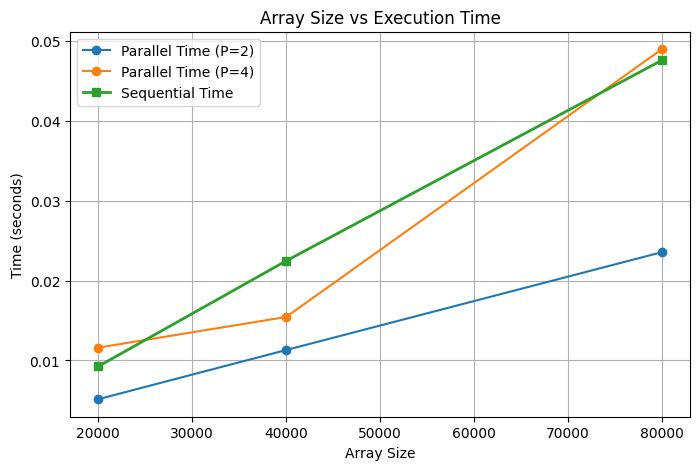

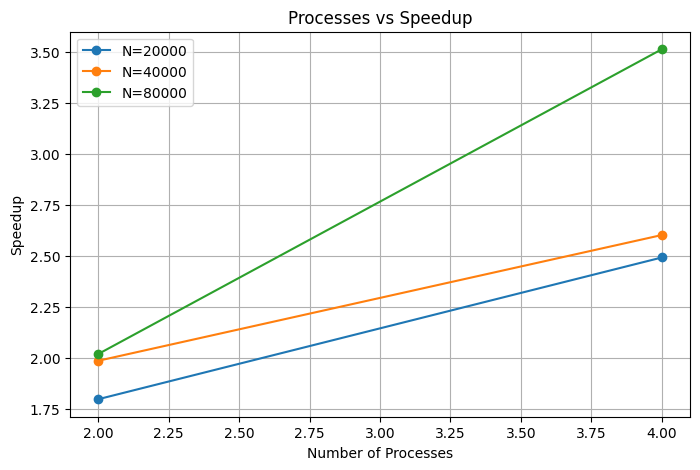

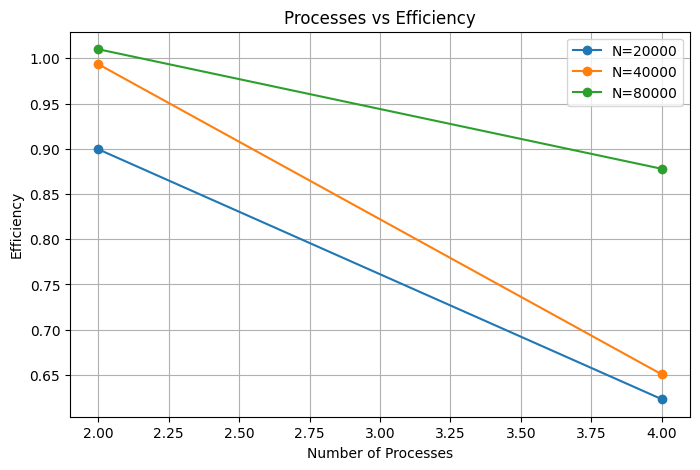

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
print(df)

# -----------------------------
# Time comparison graph
# -----------------------------
plt.figure(figsize=(8,5))
for p in sorted(df["processes"].unique()):
    temp = df[df["processes"] == p]
    plt.plot(temp["array_size"], temp["parallel_time"], marker='o', label=f'Parallel Time (P={p})')

# Sequential times (same x, repeated values)
seq_df = df.drop_duplicates(subset=["array_size"])
plt.plot(seq_df["array_size"], seq_df["sequential_time"], marker='s', linewidth=2, label='Sequential Time')

plt.title("Array Size vs Execution Time")
plt.xlabel("Array Size")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Speedup graph
# -----------------------------
plt.figure(figsize=(8,5))
for n in sorted(df["array_size"].unique()):
    temp = df[df["array_size"] == n]
    plt.plot(temp["processes"], temp["speedup"], marker='o', label=f'N={n}')

plt.title("Processes vs Speedup")
plt.xlabel("Number of Processes")
plt.ylabel("Speedup")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Efficiency graph
# -----------------------------
plt.figure(figsize=(8,5))
for n in sorted(df["array_size"].unique()):
    temp = df[df["array_size"] == n]
    plt.plot(temp["processes"], temp["efficiency"], marker='o', label=f'N={n}')

plt.title("Processes vs Efficiency")
plt.xlabel("Number of Processes")
plt.ylabel("Efficiency")
plt.legend()
plt.grid(True)
plt.show()